[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lasseufpa/dsp2026/blob/main/notebooks/exemplos/examples_1C.ipynb)

1.8 Relating Frequencies of Continuous and Discrete-Time Signals

Listing 1.14: Two methods for generating a sampled cosine signal and comparing them

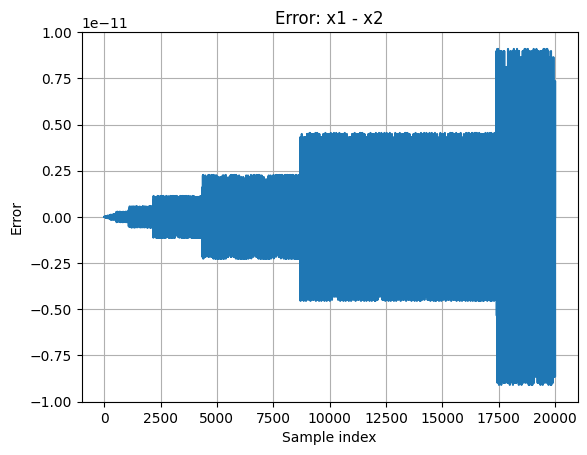

In [2]:
import numpy as np
from IPython.display import Audio, display

import matplotlib.pyplot as plt

Fs = 8000  # sampling frequency (Hz)
Ts = 1 / Fs  # sampling interval (seconds)
N = 20000  # number of desired samples
f0 = 600  # cosine frequency (Hz)

# First alternative: generate cosine in continuous-time sampled grid
t = np.arange(N) * Ts
x1 = 5 * np.cos(2 * np.pi * f0 * t)  # amplitude = 5 V

# Second alternative: work directly in discrete-time
w0 = 2 * np.pi * f0 * Ts  # digital radian frequency (rad/sample)
n = np.arange(N)  # discrete-time index
x2 = 5 * np.cos(w0 * n)  # amplitude = 5 V

# Plot error between two alternatives
plt.plot(x1 - x2)
plt.title("Error: x1 - x2")
plt.xlabel("Sample index")
plt.ylabel("Error")
plt.grid(True)
plt.show()

"Note that the sequences x1 and x2 are essentially the same, and there are only small
numerical errors. In essence, one can simulate discrete-time signals representing the
time evolution either with n (an integer) or t (in seconds), but properly using the
corresponding angular frequencies Ω (in radians) or ω (in rad/s), respectively."
-> Pg. 58

1.8.3 Nyquist frequency

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets

def ver(Ω_em_pi=0.3):
    Ω = Ω_em_pi * np.pi
    n = np.arange(0, 30)
    x_discreto = np.cos(Ω * n)

    # Continuous-time signal for visualization
    t = np.linspace(0, 29, 500)
    x_cont = np.cos(Ω * t)

    plt.figure(figsize=(20, 6))

    plt.plot(t, x_cont, 'r-', alpha=0.6, linewidth=2, label='continuous-time signal')
    plt.stem(n, x_discreto, label='samples x[n]')
    plt.plot(n, x_discreto, 'b-', alpha=0.4)

    plt.title(f'x[n] = cos(Ω n)    →    Ω = {Ω_em_pi:.3f} π rad/samples', fontsize=16)
    plt.xlabel('n (samples)')
    plt.ylabel('amplitude')
    plt.xticks(np.arange(0, 30))
    plt.ylim(-1.15, 1.15)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(ver,
         Ω_em_pi=widgets.FloatSlider(min=0, max=2.0, step=0.05, value=0.3,
                                     description='Ω / π',
                                     style={'description_width': 'initial'}));

interactive(children=(FloatSlider(value=0.3, description='Ω / π', max=2.0, step=0.05, style=SliderStyle(descri…

1.9.5 Design of uniform quantizers

a) based on input’s statistics

Quantizer parameters:
Levels (L): 8
Step size (Δ): 0.7407
Range: [-2.9811, 2.9442]
MSE: 0.047171


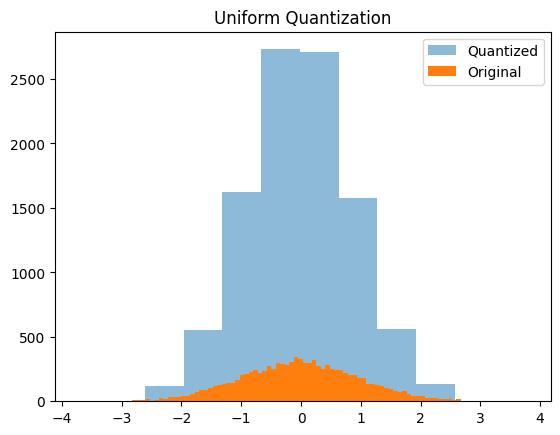

In [19]:
import numpy as np
import matplotlib.pyplot as plt


class UniformQuantizer:
    def __init__(self, bits=3, method="midrise", clipping="3sigma"):
        self.bits = bits
        self.L = 2**bits
        self.method = method
        self.clipping = clipping

    def fit(self, x):
        """Estimate quantizer parameters from input statistics"""
        self.mean = np.mean(x)
        self.std = np.std(x)

        if self.clipping == "minmax":
            self.x_min = np.min(x)
            self.x_max = np.max(x)
        elif self.clipping == "3sigma":
            self.x_min = self.mean - 3 * self.std
            self.x_max = self.mean + 3 * self.std
        elif self.clipping == "percentile":
            self.x_min = np.percentile(x, 1)
            self.x_max = np.percentile(x, 99)
        else:
            raise ValueError("Invalid clipping method")

        self.delta = (self.x_max - self.x_min) / self.L

        return self

    def quantize(self, x):
        """Quantize input signal"""
        x_clipped = np.clip(x, self.x_min, self.x_max)

        indices = np.floor((x_clipped - self.x_min) / self.delta)

        indices = np.clip(indices, 0, self.L - 1)

        if self.method == "midrise":
            q = self.x_min + (indices + 0.5) * self.delta
        elif self.method == "midtread":
            q = self.x_min + indices * self.delta
        else:
            raise ValueError("Invalid quantization method")

        return q, indices.astype(int)

    def mse(self, x, q):
        return np.mean((x - q) ** 2)

np.random.seed(0)
x = np.random.normal(loc=0, scale=1, size=10000)

quantizer = UniformQuantizer(bits=3, method="midrise", clipping="3sigma")
quantizer.fit(x)

q, indices = quantizer.quantize(x)

mse = quantizer.mse(x, q)

print("Quantizer parameters:")
print(f"Levels (L): {quantizer.L}")
print(f"Step size (Δ): {quantizer.delta:.4f}")
print(f"Range: [{quantizer.x_min:.4f}, {quantizer.x_max:.4f}]")
print(f"MSE: {mse:.6f}")

plt.figure()
plt.hist(q, bins=quantizer.L, alpha=0.5, label="Quantized")
plt.hist(x, bins=100, alpha=1, label="Original")
plt.legend()
plt.title("Uniform Quantization")
plt.show()

b) based on input’s dynamic range

Dynamic Range Quantizer:
x_min: -3.6564
x_max: 4.0268
Step size (Δ): 0.9604
MSE: 0.077078


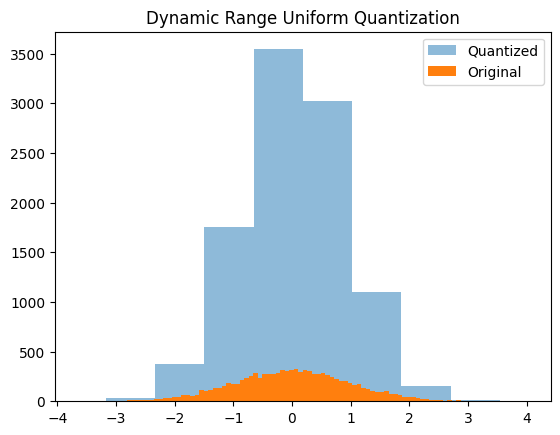

In [20]:
import numpy as np
import matplotlib.pyplot as plt

class DynamicRangeUniformQuantizer:
    def __init__(self, bits=3, method="midrise"):
        self.bits = bits
        self.L = 2 ** bits
        self.method = method

    def fit(self, x):
        """Determine quantizer range strictly from dynamic range"""
        self.x_min = np.min(x)
        self.x_max = np.max(x)

        if self.x_max == self.x_min:
            raise ValueError("Signal has zero dynamic range.")

        self.delta = (self.x_max - self.x_min) / self.L
        return self

    def quantize(self, x):
        """Quantize signal using dynamic range"""
        indices = np.floor((x - self.x_min) / self.delta)

        # Handle edge case where x == x_max
        indices = np.clip(indices, 0, self.L - 1)

        if self.method == "midrise":
            q = self.x_min + (indices + 0.5) * self.delta
        elif self.method == "midtread":
            q = self.x_min + indices * self.delta
        else:
            raise ValueError("Invalid method")

        return q, indices.astype(int)

    def mse(self, x, q):
        return np.mean((x - q) ** 2)


np.random.seed(1)

# Example signal (can be anything)
x = np.random.normal(0, 1, 10000)

quantizer = DynamicRangeUniformQuantizer(bits=3)
quantizer.fit(x)

q, indices = quantizer.quantize(x)

print("Dynamic Range Quantizer:")
print(f"x_min: {quantizer.x_min:.4f}")
print(f"x_max: {quantizer.x_max:.4f}")
print(f"Step size (Δ): {quantizer.delta:.4f}")
print(f"MSE: {quantizer.mse(x, q):.6f}")

plt.figure()
plt.hist(q, bins=quantizer.L, alpha=0.5, label="Quantized")
plt.hist(x, bins=100, alpha=1, label="Original")
plt.legend()
plt.title("Dynamic Range Uniform Quantization")
plt.show()

1.9.6 Design of optimum non-uniform quantizers

Lloyd-Max Quantizer:
Reconstruction levels: [-2.1296697  -1.32505048 -0.73739582 -0.2186702   0.27474787  0.78380567
  1.37492078  2.18734842]
MSE: 0.035219


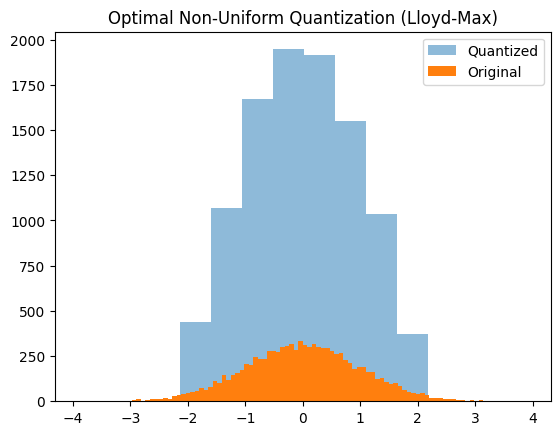

In [21]:
import numpy as np
import matplotlib.pyplot as plt

class LloydMaxQuantizer:
    def __init__(self, bits=3, max_iter=100, tol=1e-6):
        self.bits = bits
        self.L = 2 ** bits
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, x):
        """Train Lloyd-Max quantizer using input samples"""
        x = np.asarray(x)

        # Initialize reconstruction levels uniformly
        self.y = np.linspace(np.min(x), np.max(x), self.L)

        for _ in range(self.max_iter):
            y_old = self.y.copy()

            # Step 1: Compute decision boundaries
            b = np.zeros(self.L + 1)
            b[0] = np.min(x)
            b[-1] = np.max(x)

            for i in range(1, self.L):
                b[i] = 0.5 * (self.y[i-1] + self.y[i])

            # Step 2: Update centroids
            for i in range(self.L):
                mask = (x >= b[i]) & (x < b[i+1])
                if np.any(mask):
                    self.y[i] = np.mean(x[mask])

            if np.linalg.norm(self.y - y_old) < self.tol:
                break

        self.boundaries = b
        return self

    def quantize(self, x):
        """Quantize using trained levels"""
        x = np.asarray(x)

        indices = np.zeros_like(x, dtype=int)

        for i in range(self.L):
            if i == self.L - 1:
                mask = (x >= self.boundaries[i]) & (x <= self.boundaries[i+1])
            else:
                mask = (x >= self.boundaries[i]) & (x < self.boundaries[i+1])
            indices[mask] = i

        q = self.y[indices]
        return q, indices

    def mse(self, x, q):
        return np.mean((x - q) ** 2)


np.random.seed(42)

# Example: Gaussian input
x = np.random.normal(0, 1, 10000)

quantizer = LloydMaxQuantizer(bits=3)
quantizer.fit(x)

q, indices = quantizer.quantize(x)

print("Lloyd-Max Quantizer:")
print(f"Reconstruction levels: {quantizer.y}")
print(f"MSE: {quantizer.mse(x, q):.6f}")

plt.figure()
plt.hist(q, bins=quantizer.L, alpha=0.5, label="Quantized")
plt.hist(x, bins=100, alpha=1, label="Original")
plt.legend()
plt.title("Optimal Non-Uniform Quantization (Lloyd-Max)")
plt.show()

## Extra:

### Exemplo: Quantização Escalar de Imagens

O objetivo principal deste notebook é explorar os fundamentos da conversão de sinais para o domínio digital, focando especificamente na **quantização escalar uniforme** aplicada a sinais multidimensionais (imagens coloridas).

**Neste notebook, abordaremos:**

* **Design de Quantizadores Uniformes:** Como mapear a faixa dinâmica de um sinal em um livro de códigos finito ($M = 2^b$), calculando matematicamente o passo de quantização ($\Delta$) e os limites da representação discreta.
* **O Desafio dos Sinais Multidimensionais:** Uma análise crítica das limitações teóricas e visuais da quantização escalar clássica em contraste com técnicas avançadas de compressão.

Além de bibliotecas padrão do Python, vamos importar um código direto de um repositório do GitHub. Ele contém a classe `UniformQuantizer`, que já tem toda a lógica matemática da quantização uniforme pronta para usarmos.

🔎 Se você se interessar em entender como o código funciona "por baixo dos panos", sinta-se à vontade para acessar o link do GitHub no código ou investigar aqui mesmo após importar a biblioteca!

In [ ]:
# Clone the repository if running in Colab and install all the dependencies
if 'google.colab' in str(get_ipython()):
    import sys
    import os
    try:
      !git clone https://github.com/lasseufpa/lasse-py.git
    except:
      print("lasse-py is already in the contents")
    %cd lasse-py
    !pip install -r requirements.txt
else:
    import sys
    # make sure to set the path to where you have cloned the LASSE repository
    # under your folder specified below, you need to find lasse/dsp, lasse/audio, etc.
    sys.path.append(r"C:\github\lasse-py")
    import lasse.dsp  # verify if the module is correctly imported

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from lasse.dsp.scalar_quantization import UniformQuantizer # Nosso módulo de quantização

In [ ]:
# Lendo uma imagem
url = "https://raw.githubusercontent.com/lasseufpa/dsp-notebooks/main/Ch1_Signals/input_data/baboon.tiff"
response = requests.get(url)
x = Image.open(BytesIO(response.content))
x = np.array(x)

# Visualizando a imagem original
plt.figure(figsize=(10, 6))
plt.imshow(x)
plt.title('Original image')
plt.axis('off')
plt.show()

Antes da matemática, convertemos a matriz da imagem de inteiros sem sinal (`uint8`) para pontos flutuantes (`np.float64`). Isso é fundamental para evitar erros de *overflow* e perda de precisão durante as divisões decimais no cálculo dos níveis.

In [ ]:
x_double = x.astype(np.float64)  # convertendo de uint8 para double

### 2. Design do quantizador

O quantizador $Q : R \rightarrow ℳ$ atua mapeando os valores da entrada para um conjunto menor com um número finito de elementos $ℳ$, chamado de **livro de códigos** (*codebook*).

A cardinalidade deste conjunto é tipicamente $M = 2^b$, onde $b$ é o número de bits usados. Em um **quantizador uniforme**, a relação de entrada/saída impõe uma partição do espaço em degraus que possuem altura e largura idênticas, iguais ao tamanho do passo $\Delta$.

In [ ]:
# O passo de quantização
b = 4
delta = 256 / (2 ** b)

Para projetar o quantizador, adotamos a estratégia baseada na faixa dinâmica de entrada $[X_{min}​,X_{max}​]$, em que $\hat{X}_{min} = X_{min}$. A Equação (1.42) do livro-texto define o passo como:

$$\Delta = \frac{X_{max} - X_{min}}{M}$$

Em uma imagem de 8 bits, os pixels variam de $X_{min}​=0$ a $X_{max}​=255$, o que resultaria em um numerador teórico de $255$. No entanto, na implementação prática computacional (refletida na variável `delta`), aproxima-se essa faixa pela capacidade total de estados do canal ($2^{8}=256$). Essa simplificação trata o intervalo de intensidades como um espaço contínuo de 256 unidades, garantindo passos de tamanho inteiro ($Δ=16$).

In [ ]:
# Instanciando o quantizador
uniformQuantizer = UniformQuantizer(
    num_bits=b,
    delta=delta,
    xminq=0
)

O quantizador uniforme é definido pelos parâmetros $b$, $\Delta$ e a saída mínima $\hat{X}_{min}$.

Adotando a estratégia de igualar a base à faixa original, fazemos $\hat{X}_{min} = X_{min} = 0$. Uma consequência geométrica dessa escolha é que a saída máxima do quantizador ($\hat{X}_{max}$) não atinge a capacidade total teórica. Ela é regida pela equação:

$$\hat{X}_{max} = \hat{X}_{min} + (M - 1)\Delta$$

Isso explica o comportamento prático do algoritmo: para $b=4$ (com $\Delta=16$), o maior nível quantizado que a imagem pode assumir é $0 + (16 - 1)16 = 240$.

### 3. Quantização, histogramas e visualização da imagem quantizada

In [ ]:
# Quantizando a imagem
xq_double, x_indices = uniformQuantizer._quantize_implementation(x_double)

print(f"Maximum quantized value: {np.max(xq_double)}")
print(f"Minimum quantized value: {np.min(xq_double)}")

Com o quantizador devidamente configurado (possuindo os parâmetros $b$, $\Delta$ e $\hat{X}_{min}$ definidos), aplicamos o modelo matemático à matriz da imagem.

O método interno de quantização atua em duas fases para cada pixel:
1. **Compressão/Índice:** Subtrai a base ($\hat{X}_{min}$), divide pelo passo $\Delta$ e arredonda para o inteiro mais próximo. Isso descobre em qual "degrau" (ou índice do dicionário) o pixel caiu.
2. **Expansão/Reconstrução:** Multiplica o índice resultante pelo passo $\Delta$ e soma a base ($\hat{X}_{min}$) novamente para obter o valor de intensidade real do pixel quantizado.

Os prints de valor máximo e mínimo servem como uma verificação empírica para confirmar se o sinal reconstruído respeitou as fronteiras teóricas de $\hat{X}_{min}$ e $\hat{X}_{max}$.

A seguir, plotamos os histogramas de ambas as imagens (original e quantizada):

In [ ]:
# Plotando histogramas
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].hist(x_double.flatten(), bins=256, edgecolor='black')
axes[0].set_title('Histogram of original image (all three colors)')
axes[0].set_xlabel('Pixel value')
axes[0].set_ylabel('Frequency')

axes[1].hist(xq_double.flatten(), bins=2**b, edgecolor='black')
axes[1].set_title('Histogram of quantized image (all three colors)')
axes[1].set_xlabel('Pixel value')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Por que usamos o `.flatten()`?**
Um histograma analisa apenas a frequência das intensidades, ignorando a posição espacial dos pixels. O método `.flatten()` "achata" o tensor 3D da imagem (Altura $\times$ Largura $\times$ Cores) em um único vetor unidimensional contínuo, tratando a imagem estritamente como um fluxo de amostras (sinal 1D).

**O Efeito Visual do Livro de Códigos (*Codebook*)**
* **Sinal Original:** O histograma é plotado com `bins=256`, mostrando uma distribuição densa cobrindo quase todas as intensidades possíveis.
* **Sinal Quantizado:** O histograma é plotado com `bins=2**b`. O resultado visual é a substituição da curva contínua por *spikes* discretos. Toda a massa de dados que caía no intervalo de um degrau foi colapsada para um único valor central.

Para exibir a imagem na tela, precisamos retornar os dados ao formato padrão unipolar que os monitores e as bibliotecas gráficas (como o `matplotlib`) esperam: inteiros sem sinal de 8 bits (`uint8`).

In [ ]:
# Convertendo para uint8 e exibindo a imagem
xq = np.clip(xq_double, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 6))
plt.imshow(xq)
plt.title(f'Quantized image (b={b} bits)')
plt.axis('off')
plt.show()

Antes da conversão de tipo (.astype), aplicamos uma trava de segurança essencial: o np.clip. Mesmo que a matemática teórica garanta que a saída do quantizador fique dentro dos limites, erros microscópicos de arredondamento de ponto flutuante podem gerar valores como  255.0001  ou  −0.0001 . O clip atua como um limitador hard, forçando (ceifando) estritamente qualquer valor de volta para a faixa segura de  [0,255] . Se tentássemos converter um número negativo direto para uint8, ele daria a volta no limite (o chamado underflow matemático) e viraria um pixel branco, corrompendo a imagem visualmente.

### 4. Quantificando o erro de quantização

Por fim, podemos avaliar a qualidade da quantização não apenas utilizando nossa visão subjetiva, mas quantificando o erro introduzido no sinal pela nossa quantização uniforme.

In [ ]:
# Calculando MSE e PSNR
meanSquareError = np.mean((x.astype(np.float64).flatten() - xq.astype(np.float64).flatten()) ** 2)
print(f"Mean Square Error (MSE): {meanSquareError}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {10 * np.log10(255**2 / meanSquareError):.2f} dB")

**1. Erro Quadrático Médio (MSE - *Mean Square Error*)**
O MSE mede a "potência" do ruído de quantização. Ele calcula a diferença exata entre cada pixel original ($x$) e seu equivalente quantizado ($x_q$), eleva ao quadrado (para eliminar valores negativos e penalizar erros maiores) e extrai a média global da imagem.

**2. Relação Sinal-Ruído de Pico (PSNR - *Peak Signal-to-Noise Ratio*)**
O MSE isolado é difícil de interpretar, pois depende da escala do sinal. O PSNR normaliza essa medida, comparando o ruído (MSE) com a energia máxima teórica que o sinal pode assumir. A fórmula clássica é:

$$PSNR = 10 \cdot \log_{10}\left(\frac{MAX^2}{MSE}\right)$$

Onde $MAX = 255$ para imagens de 8 bits. O resultado é expresso em decibéis (dB). Como o MSE está no denominador, **quanto maior o PSNR, mais fiel e próxima do sinal original é a imagem quantizada**. Valores acima de 30 dB geralmente indicam excelente qualidade perceptiva.

### 5. Discussão: Quantização Escalar em Imagens RGB

Até este ponto, aplicamos ao nosso sinal uma técnica conhecida como **Quantização Escalar**. Isso significa que o algoritmo atua sobre a matriz da imagem de forma "míope": ele pega um único valor numérico, isolado de seu contexto, e o aproxima para o degrau mais próximo.

Para imagens coloridas, essa abordagem carrega consequências matemáticas e visuais importantes que merecem ser debatidas.

**1. O Orçamento de Bits em Canais RGB**
Uma imagem colorida não possui um, mas três canais superpostos: Vermelho (R), Verde (G) e Azul (B). Como o nosso `UniformQuantizer` é escalar, ele atua em cada um desses canais de forma independente.

Isso exige cuidado ao falarmos sobre a **resolução total** da imagem. Se definirmos um orçamento total de Taxa ($R$), medido em *bits por pixel*, precisamos fatiar esse orçamento entre as cores:
$$n_{canal} = \frac{R_{total}}{3}$$

Por exemplo, ao configurarmos nosso quantizador com $b=4$ bits, ele gera $16$ níveis para o Red, $16$ para o Green e $16$ para o Blue. A combinação desses canais resulta em um pixel final que consome, na verdade, **12 bits** de informação ($4+4+4$), permitindo uma paleta combinada de $16 \times 16 \times 16 = 4.096$ cores possíveis.

**2. O Custo da Quantização Escalar (Distorções e Ineficiências)**
Embora tratar a imagem pixel a pixel (como se fosse um sinal de áudio unidimensional) seja didático para entendermos a matemática da quantização, essa técnica é altamente ineficiente para sinais multidimensionais e gera artefatos visuais severos.

Em uma fotografia real, os **pixels são altamente correlacionados**. Se um pixel é azul, há uma chance imensa de o pixel ao lado também ser azul. Além disso, dentro de um mesmo pixel, os valores de $R$, $G$ e $B$ raramente são independentes; na maioria das imagens naturais, eles sobem e descem juntos para definir a claridade e o tom da cena. A quantização escalar ignora essa geometria, gastando bits para quantizar e armazenar cada cor de pixel de forma independente, como se cada número fosse uma surpresa isolada e imprevisível.

**3. A Perspectiva Multidimensional (O Mundo Real)**
Para contornar as distorções da quantização escalar, sistemas modernos de compressão de imagem abandonam essa técnica em favor de abordagens que enxergam a imagem como a matriz 2D que ela realmente é, um exemplo disso é:
* **Quantização Vetorial:** Em vez de quantizar os canais $R, G$ e $B$ separadamente, a cor do pixel é tratada como um ponto flutuando em um espaço vetorial 3D. O algoritmo cria um "dicionário" com as cores mais usadas na imagem inteira e substitui o pixel pelo índice da cor mais próxima nesse dicionário, economizando bits drasticamente.